# How well do jobs and skills pay for Data Analysts?


## Methology

1. Evaluate median salary for top 6 data jobs
2. Find median salary per skill for Data Analysts
3. Visualize for highest paying skills and most demanded skills

In [1]:
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Load the dataset
dataset = load_dataset("lukebarousse/data_jobs")
df=dataset["train"].to_pandas()

# Data Cleanup
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

C:\Users\IDEAPADGAMING\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_In=df[(df['job_country']=='India')].dropna(subset=['salary_year_avg'])

In [3]:
job_titles=df_In['job_title_short'].value_counts().head(6).index.to_list()
df_In_top6=df_In[df_In['job_title_short'].isin(job_titles)]

In [12]:
job_order=df_In_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values().index

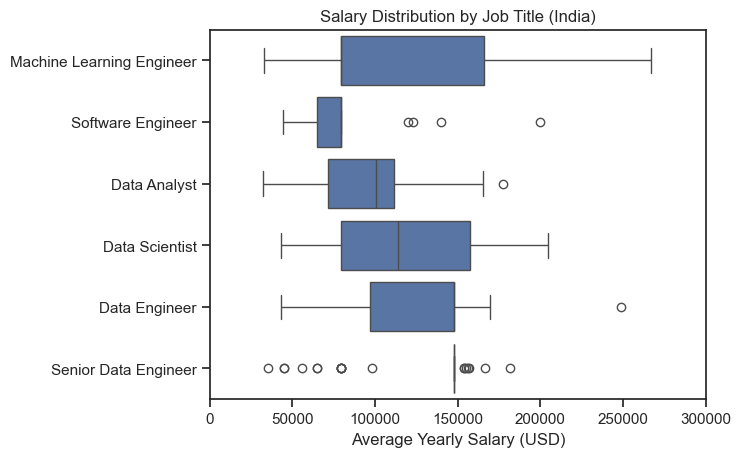

In [13]:
sns.boxplot(data=df_In_top6,x='salary_year_avg',y='job_title_short',order=job_order)
sns.set_theme(style='ticks')

plt.title('Salary Distribution by Job Title (India)')
plt.xlabel('Average Yearly Salary (USD)')
plt.ylabel('')
plt.xlim(0,300000)
plt.show()
